Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv
   StudyHours  Attendance  PreviousMarks  FinalMarks
0          23          84             73          67
1          19          64             59          61
2          24          98             91          74
3          29          89             98          71
4          19          92             65          70
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4468.8740 - mae: 66.7383 - val_loss: 4361.2002 - val_mae: 65.9351
Epoch 2/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3895.9573 - mae: 62.2670 - val_loss: 3221.6062 - val_mae: 56.6824
Epoch 3/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2269.4521 - mae: 47.1636 - val_loss: 1297.0220 - val_mae: 35.8613
Epoch 4/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 650.1931 - mae: 24.0929 - val_loss: 208.5055 - val_mae: 13.1123
Epoch 5/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 112.6790 - mae: 8.6423 - val_loss: 64.7543 - val_mae: 6.4035
Epoch 6/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 67.0949 - mae: 6.5212 - val_loss: 58.7355 - val_mae: 6.0452
Epoch 7/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 63.0013 - mae: 6.3185 - val_loss: 55.5815 - val_mae: 5.8659
Epoch 8/100
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 59.4110 - mae: 6.1262 - val_loss: 52.2464 - val_mae: 5.6748
Epoch 9/100
166/166 ━

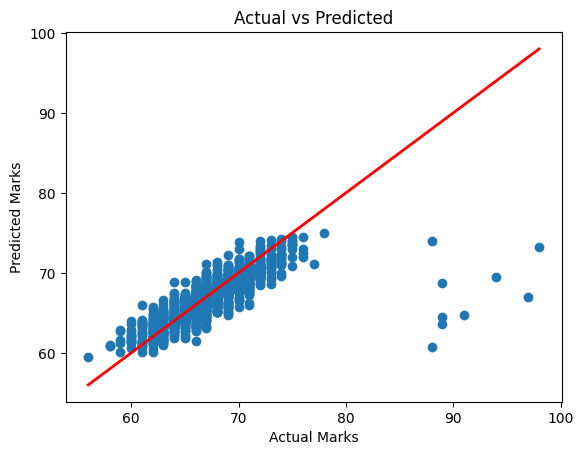

Enter Study Hours: 24
Enter Attendance: 80
Enter Previous Marks: 80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Marks: 68.18592
Result: PASS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:

#-----------------------------
# Upload dataset from PC
#-----------------------------
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
df = pd.read_csv("/content/StudentPerformanceFactors.csv")

print(df.head())

#-----------------------------
# Select Features & Target
#-----------------------------
X = df[['StudyHours', 'Attendance', 'PreviousMarks']]
y = df['FinalMarks']

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# -----------------------------
# Normalize Data
# -----------------------------
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Build Model
# -----------------------------
model = Sequential()
model.add(Dense(10, activation='relu', input_dim=3))
model.add(Dense(8, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# -----------------------------
# Train Model
# -----------------------------
model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

# -----------------------------
# Evaluate
# -----------------------------
loss, mae = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("MAE:", mae)

# -----------------------------
# Predictions
# -----------------------------
predictions = model.predict(X_test)

# -----------------------------
# Plot
# -----------------------------
plt.scatter(y_test, predictions)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red',linewidth=2)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()

# -----------------------------
# Test New Input
# -----------------------------
# -----------------------------
# Test New Input
# -----------------------------
study = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance: "))
prev = float(input("Enter Previous Marks: "))

new_student = np.array([[study, attendance, prev]])
new_student = scaler.transform(new_student)

prediction = model.predict(new_student)

predicted_marks = prediction[0][0]

print("Predicted Marks:", predicted_marks)

# -----------------------------
# Pass/Fail Decision
# -----------------------------
if predicted_marks >= 40:
    print("Result: PASS")
else:
    print("Result: FAIL")